# Laborator 5: Imagini

In [19]:
%matplotlib inline
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import rawpy
from skimage.metrics import structural_similarity as ssim
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Optional AVIF support
# pip install pillow-avif-plugin
try:
    import pillow_avif  # noqa: F401
    AVIF_AVAILABLE = True
except ImportError:
    AVIF_AVAILABLE = False
    print("Warning: pillow-avif-plugin not found — AVIF will be skipped.")


IMAGE_NAME = "dice"
RAW_IMG = 'img/683A2625.CR3'
IMG = f"img/{IMAGE_NAME}.png"
os.makedirs("output", exist_ok=True)

print(f"Marime imagine png: {os.path.getsize(IMG)} bytes")
print(f"Marime imagine raw: {os.path.getsize(RAW_IMG)} bytes")

Marime imagine png: 220991 bytes
Marime imagine raw: 39170772 bytes


### 1. Diferente intre interpolare Biliniara vs AHD pentru imaginile RAW

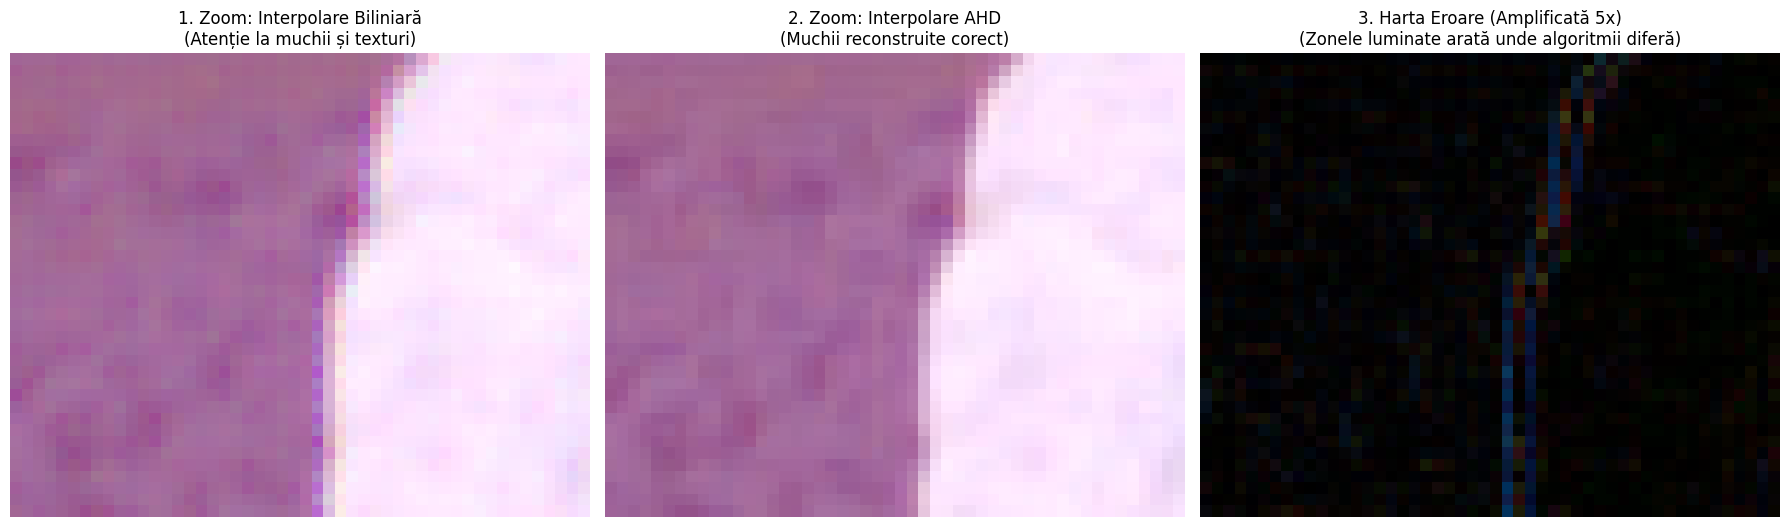

In [20]:
with rawpy.imread(RAW_IMG) as raw:
    # 1. Interpolare Biliniară
    rgb_bilinear = raw.postprocess(
        demosaic_algorithm=rawpy.DemosaicAlgorithm.LINEAR, 
        use_camera_wb=True, 
        half_size=False
    )

    # 2. Interpolare AHD (Adaptivă)
    rgb_ahd = raw.postprocess(
        demosaic_algorithm=rawpy.DemosaicAlgorithm.AHD, 
        use_camera_wb=True, 
        half_size=False
    )

# Aici facem zoom-ul
# Definim coordonatele ferestrei pe care vrem să o studiem.
# Pentru un fișier CR3 mare, poți ajusta aceste valori ca să "pice" exact pe un detaliu.
# Se va extrage un pătrat de 400x400 pixeli.
y_start, y_end = 2780, 2820 # Liniile matricei (axa verticală Y)
x_start, x_end = 3020, 3070  # Coloanele matricei (axa orizontală X)

# Aplicăm "zoom-ul" (slicing pe array-uri numpy)
crop_bilinear = rgb_bilinear[y_start:y_end, x_start:x_end]
crop_ahd = rgb_ahd[y_start:y_end, x_start:x_end]

# --- CALCULUL DIFERENȚEI ---
# 3. Convertim la int32 INAINTE de a scădea, pentru a evita wrap-around-ul matematic al formatului uint8.
diff_int = np.abs(crop_ahd.astype(np.int32) - crop_bilinear.astype(np.int32))

amplifying_factor = 2.5
# Amplificăm diferența ca pixelii diferiți să iasă în evidență.
# np.clip oprește valorile la maxim 255 pentru a putea afișa corect imaginea ca uint8.
diff_amplified = np.clip(diff_int * amplifying_factor, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(crop_bilinear)
axs[0].set_title("1. Zoom: Interpolare Biliniară\n(Atenție la muchii și texturi)", fontsize=12)
axs[0].axis('off')

axs[1].imshow(crop_ahd)
axs[1].set_title("2. Zoom: Interpolare AHD\n(Muchii reconstruite corect)", fontsize=12)
axs[1].axis('off')

axs[2].imshow(diff_amplified)
axs[2].set_title("3. Harta Eroare (Amplificată 5x)\n(Zonele luminate arată unde algoritmii diferă)", fontsize=12)
axs[2].axis('off')

plt.tight_layout()
plt.show()

## 2. Salvează imaginea ca fișier jpeg și vezi dimensiunea ei

Quality 10: 12014 bytes
Quality 20: 15029 bytes
Quality 30: 17490 bytes
Quality 40: 19610 bytes
Quality 50: 21723 bytes
Quality 60: 23876 bytes
Quality 70: 27268 bytes
Quality 80: 32948 bytes
Quality 90: 45992 bytes
Quality 100: 127464 bytes


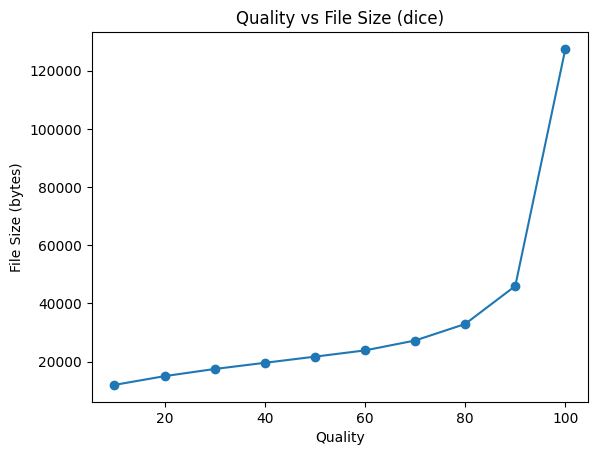

Saved output/quality_vs_size_dice.png


In [21]:
qualities = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

img = Image.open(IMG)

# Convertim imaginea in RGB deoarece formatul original este RGBA (cu canal alpha)
# si formatul JPEG nu suporta canal alpha
img_rgb = img.convert("RGB")

for q in qualities:
    path = f"output/{IMAGE_NAME}_q{q}.jpg"
    img_rgb.save(path, "JPEG", quality=q)
    print(f"Quality {q}: {os.path.getsize(f'output/{IMAGE_NAME}_q{q}.jpg')} bytes")

sizes_jpeg = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.jpg") for q in qualities] # aici genereaza vectorul de dimensiuni


# Acuma plotam rezultatele
plt.figure()
plt.plot(qualities, sizes_jpeg, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

## Acuma pentru acceasi imagine, folosim WEBP si AVIF

### Pentru WebP

Quality 10: 38928 bytes
Quality 20: 39708 bytes
Quality 30: 40680 bytes
Quality 40: 41900 bytes
Quality 50: 43026 bytes
Quality 60: 44006 bytes
Quality 70: 45064 bytes
Quality 80: 48146 bytes
Quality 90: 56440 bytes
Quality 100: 85944 bytes


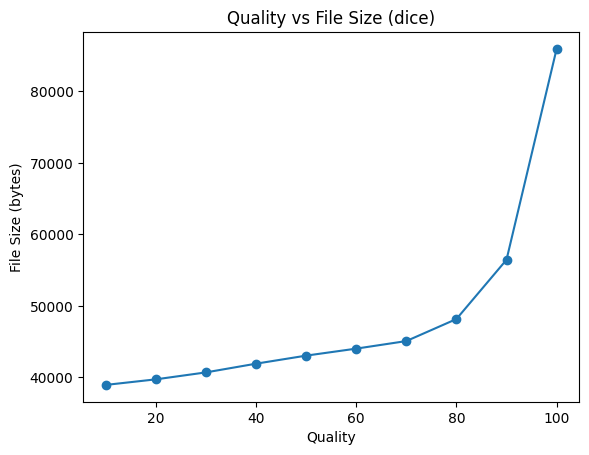

Saved output/quality_vs_size_dice.png


In [22]:
# TODO: completeaza codul ca sa vezi diferentele si pt WebP
# in mare parte trebuie sa copiezi codul de sus si sa faci mici schimbari

for q in qualities:
    path = f"output/{IMAGE_NAME}_q{q}.webp"
    img.save(path, "WEBP", quality=q)
    print(f"Quality {q}: {os.path.getsize(path)} bytes")

sizes_webp = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.webp") for q in qualities] # aici genereaza vectorul de dimensiuni

# Plotam rezultatele
plt.figure()
plt.plot(qualities, sizes_webp, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

### Pentru AVIF:

Quality 10: 4057 bytes
Quality 20: 5349 bytes
Quality 30: 6826 bytes
Quality 40: 9126 bytes
Quality 50: 12004 bytes
Quality 60: 17182 bytes
Quality 70: 22073 bytes
Quality 80: 28254 bytes
Quality 90: 45360 bytes
Quality 100: 122736 bytes


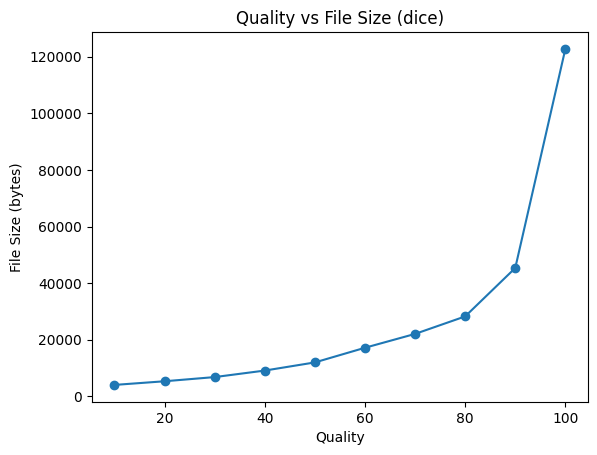

Saved output/quality_vs_size_dice.png


In [23]:
# TODO: completeaza codul ca sa vezi diferentele si pt AVIF
# in mare parte trebuie sa copiezi codul de sus si sa faci mici schimbari
for q in qualities:
    path = f"output/{IMAGE_NAME}_q{q}.avif"
    img.save(path, "AVIF", quality=q)
    print(f"Quality {q}: {os.path.getsize(path)} bytes")

sizes_avif = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.avif") for q in qualities]

plt.figure()
plt.plot(qualities, sizes_avif, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

### Acuma le plotam pe toate intre ele

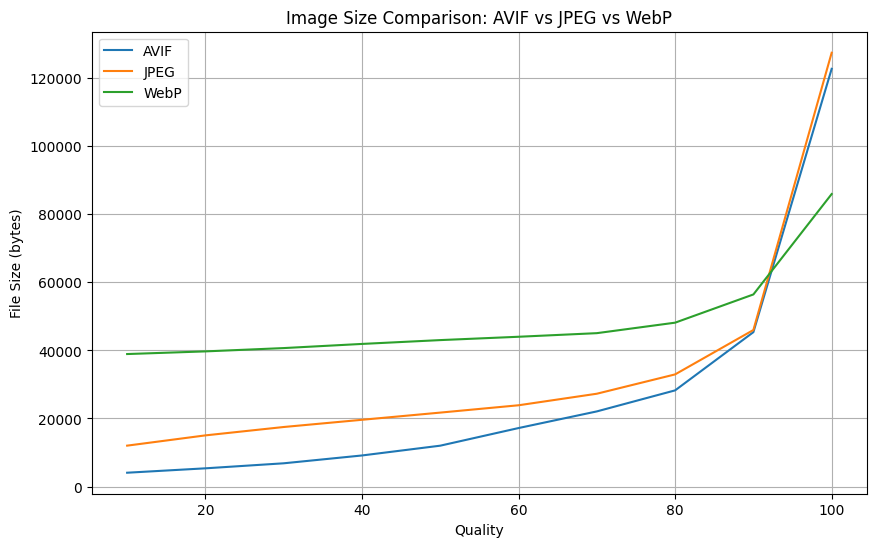

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(qualities, sizes_avif, label='AVIF')
plt.plot(qualities, sizes_jpeg, label='JPEG')
plt.plot(qualities, sizes_webp, label='WebP')
plt.xlabel('Quality')
plt.ylabel('File Size (bytes)')
plt.title('Image Size Comparison: AVIF vs JPEG vs WebP')
plt.legend()
plt.grid(True)
plt.show()

## 3. Comparație vizuală: original vs JPEG

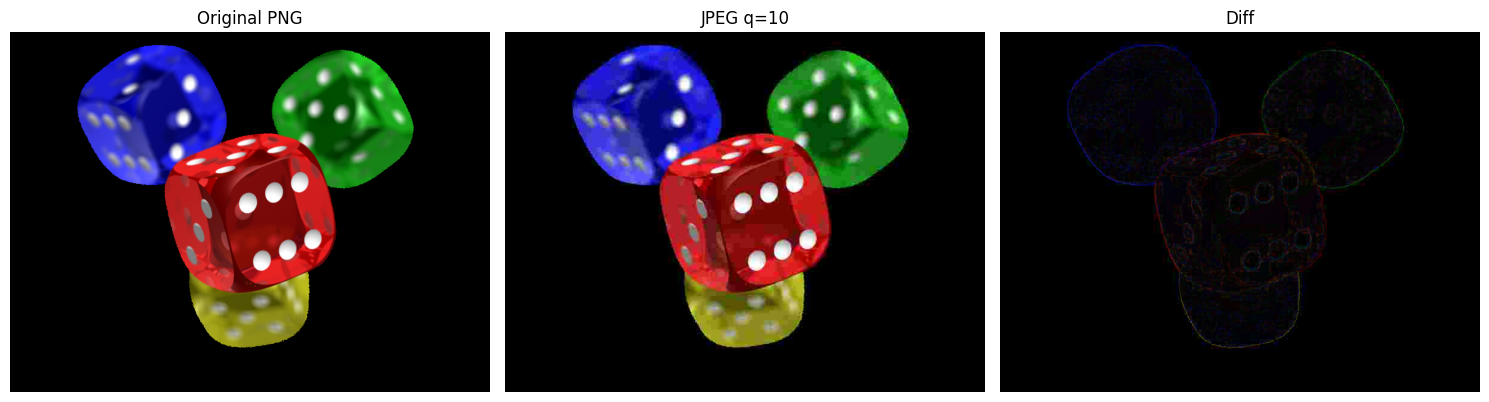

In [25]:
# Putem sa facem si pt jpeg si pt avif
original   = np.array(Image.open(IMG).convert("RGB"))
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.jpg").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG"); axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title(f"JPEG q=10");    axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");         axes[2].axis("off")
plt.tight_layout()
plt.show()

# 3.1 Comparație vizuală: original vs WebP

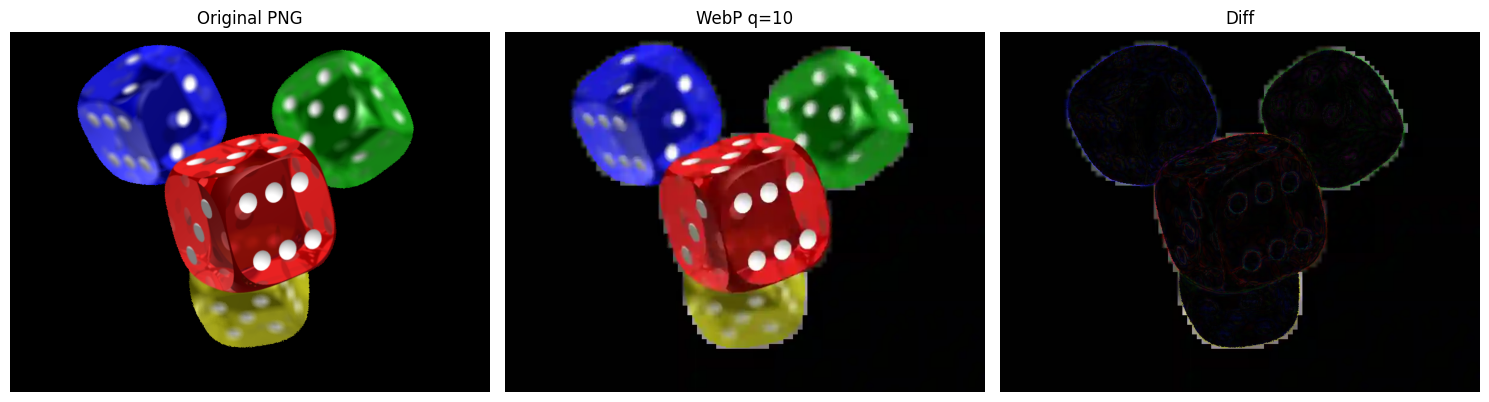

In [26]:
# TODO: asta o sa il aiba de implementat
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.webp").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG");  axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title("WebP q=10");     axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");          axes[2].axis("off")
plt.tight_layout()
plt.show()

# 3.2 Comparație vizuală: original vs AVIF

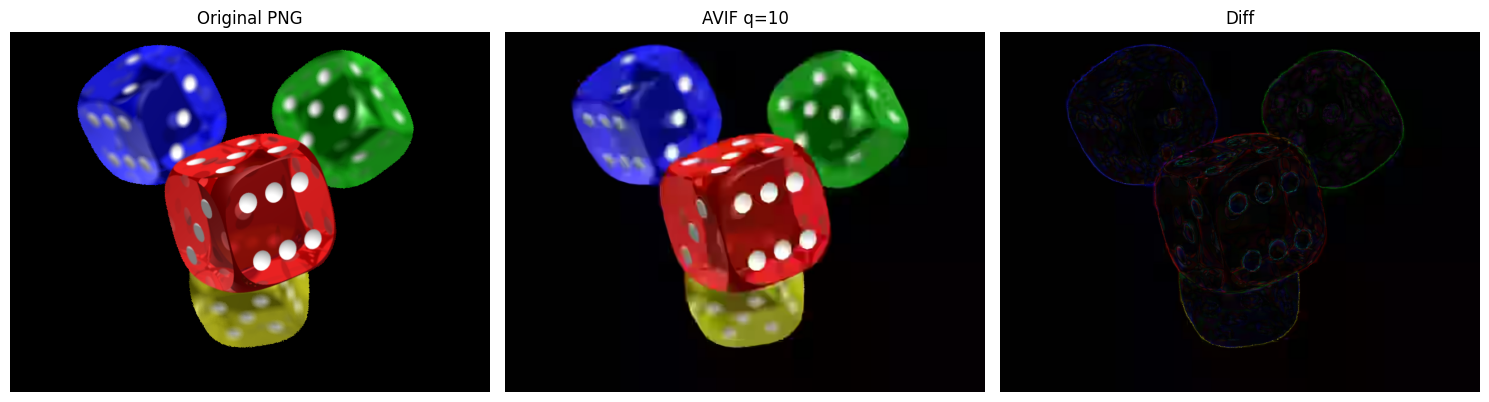

In [27]:
# TODO: asta o sa il aiba de implementat
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.avif").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG");  axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title("AVIF q=10");     axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");          axes[2].axis("off")
plt.tight_layout()
plt.show()

## 4. Comparam algoritmi de compresie pe o imagine "cu zgomot"

In [28]:
noise = np.random.randint(0, 255, (10000, 1000, 3), dtype=np.uint8)
noise_img = Image.fromarray(noise)

# format: lista de (nume, format PIL, extra kwargs - argumente ce vor fi pasate la noise_img.save)
# TODO: adauga mai multe formate si verifica cum compreseaza "zgomotul"
formats = [
    ("png",            "PNG",  {}),
    ("webp",           "WEBP", {}), # si asta probabil
    ("webp_lossless",  "WEBP", {"lossless": True}), # probabil asta o sa il aiba de adaugat
    ("jpg",            "JPEG", {}),
    ("tif",            "TIFF", {}), # asta la fel
    ("tif_lzw",        "TIFF", {"compression": "tiff_lzw"}), # unul dintre astea o sa il scot
    ("tif_deflate",    "TIFF", {"compression": "tiff_deflate"}),
    ("bmp",            "BMP",  {}),
]
if AVIF_AVAILABLE:
    formats.append(("avif", "AVIF", {}))

for name, fmt, kwargs in formats:
    path = f"output/noise_{name}.{name.split('_')[0]}"
    noise_img.save(path, format=fmt, **kwargs) # adica aici!!
    size = os.path.getsize(path)
    print(f"{name:<14} size: {size / 1024:.2f} KB")

png            size: 29325.33 KB
webp           size: 6605.38 KB
webp_lossless  size: 29282.35 KB
jpg            size: 5867.92 KB
tif            size: 29297.01 KB
tif_lzw        size: 40119.13 KB
tif_deflate    size: 29312.84 KB
bmp            size: 29296.93 KB
avif           size: 7690.43 KB


## 5. Metrici de calitate a imaginilor

In [ ]:
# https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio 
# TLDR: cat de mult difera cele 2 imagini, cu cat e mai mare cu atat mai bine
def compute_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255.0 ** 2) / mse)

# https://en.wikipedia.org/wiki/Structural_similarity_index_measure 
# TLDR: cat de similare sunt cele 2 imagini, cu cat e mai aproape de 1 cu atat mai bine (cuprins intre -1 si 1)
# aici o sa masuram luminozitatea si contrastul, de aceea avem nevoie de formatul YCrCb sau YUV
# https://en.wikipedia.org/wiki/YUV
def compute_ssim(img1, img2):
    y1 = cv2.cvtColor(img1, cv2.COLOR_RGB2YCrCb)[:, :, 0]
    y2 = cv2.cvtColor(img2, cv2.COLOR_RGB2YCrCb)[:, :, 0]
    score, _ = ssim(y1, y2, full=True)
    return score

### 5.1 JPEG

Quality  10 | PSNR: 35.42 dB | SSIM: 0.9429
Quality  20 | PSNR: 37.05 dB | SSIM: 0.9637
Quality  30 | PSNR: 37.99 dB | SSIM: 0.9712
Quality  40 | PSNR: 38.28 dB | SSIM: 0.8887
Quality  50 | PSNR: 39.03 dB | SSIM: 0.9774
Quality  60 | PSNR: 39.50 dB | SSIM: 0.9797
Quality  70 | PSNR: 39.60 dB | SSIM: 0.8957
Quality  80 | PSNR: 40.79 dB | SSIM: 0.9861
Quality  90 | PSNR: 42.27 dB | SSIM: 0.9917
Quality 100 | PSNR: 45.25 dB | SSIM: 0.9989


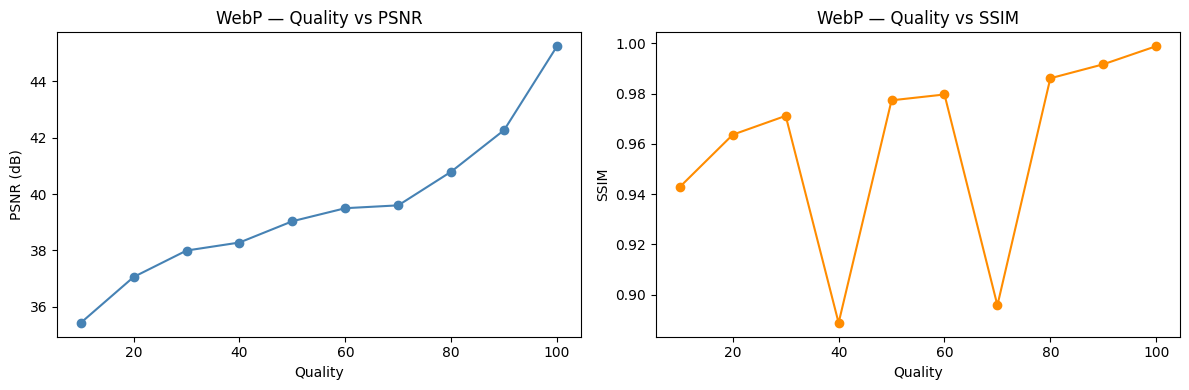

Saved output/quality_metrics.png


In [30]:
# JPEG
original   = np.array(Image.open(IMG).convert("RGB"))
results_jpg = []
for q in qualities:
    comp = np.array(Image.open(f"output/{IMAGE_NAME}_q{q}.jpg").convert("RGB"))
    results_jpg.append((q, compute_psnr(original, comp), compute_ssim(original, comp)))
    print(f"Quality {q:3d} | PSNR: {results_jpg[-1][1]:.2f} dB | SSIM: {results_jpg[-1][2]:.4f}")

qs, psnrs, ssims_vals = zip(*results_jpg)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(qs, psnrs,      marker="o", color="steelblue");  ax1.set_xlabel("Quality"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("WebP — Quality vs PSNR")
ax2.plot(qs, ssims_vals, marker="o", color="darkorange"); ax2.set_xlabel("Quality"); ax2.set_ylabel("SSIM");      ax2.set_title("WebP — Quality vs SSIM")
plt.tight_layout()
plt.savefig("output/quality_metrics.png")
plt.show()
print("Saved output/quality_metrics.png")

Quality  10 | PSNR: 36.22 dB | SSIM: 0.8473
Quality  20 | PSNR: 37.03 dB | SSIM: 0.9327
Quality  30 | PSNR: 37.51 dB | SSIM: 0.9363
Quality  40 | PSNR: 38.05 dB | SSIM: 0.9383
Quality  50 | PSNR: 38.39 dB | SSIM: 0.9410
Quality  60 | PSNR: 38.69 dB | SSIM: 0.9421
Quality  70 | PSNR: 39.05 dB | SSIM: 0.9443
Quality  80 | PSNR: 40.04 dB | SSIM: 0.9480
Quality  90 | PSNR: 40.69 dB | SSIM: 0.9489
Quality 100 | PSNR: 42.33 dB | SSIM: 0.9536


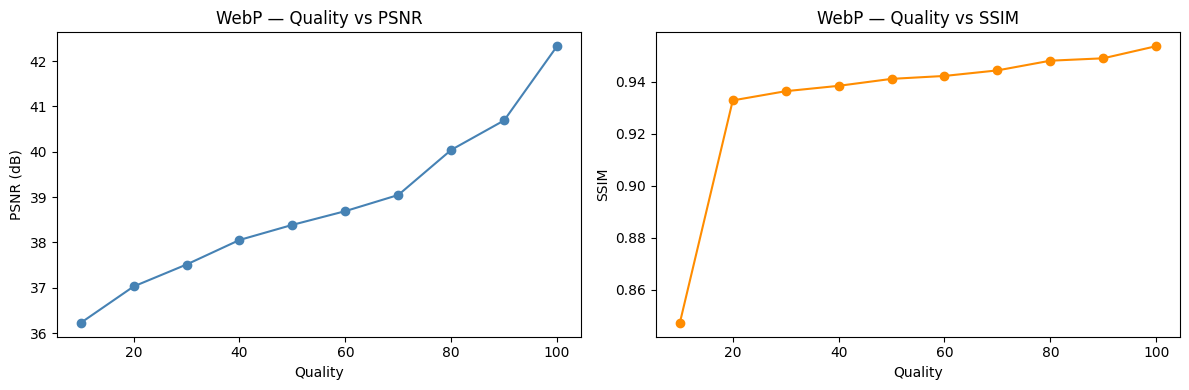

Saved output/quality_metrics.png


In [31]:
# WebP
# TODO: completeaza codul aici, la fel ca celelalte sectiuni te poti inspira de sus
results_webp = []
for q in qualities:
    comp = np.array(Image.open(f"output/{IMAGE_NAME}_q{q}.webp").convert("RGB"))
    results_webp.append((q, compute_psnr(original, comp), compute_ssim(original, comp)))
    print(f"Quality {q:3d} | PSNR: {results_webp[-1][1]:.2f} dB | SSIM: {results_webp[-1][2]:.4f}")

qs, psnrs, ssims_vals = zip(*results_webp)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(qs, psnrs,      marker="o", color="steelblue");  ax1.set_xlabel("Quality"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("WebP — Quality vs PSNR")
ax2.plot(qs, ssims_vals, marker="o", color="darkorange"); ax2.set_xlabel("Quality"); ax2.set_ylabel("SSIM");      ax2.set_title("WebP — Quality vs SSIM")
plt.tight_layout()
plt.savefig("output/quality_metrics.png")
plt.show()
print("Saved output/quality_metrics.png")

Quality  10 | PSNR: 35.25 dB | SSIM: 0.8446
Quality  20 | PSNR: 36.66 dB | SSIM: 0.9184
Quality  30 | PSNR: 38.09 dB | SSIM: 0.9681
Quality  40 | PSNR: 39.08 dB | SSIM: 0.9633
Quality  50 | PSNR: 40.52 dB | SSIM: 0.9866
Quality  60 | PSNR: 41.75 dB | SSIM: 0.9913
Quality  70 | PSNR: 42.43 dB | SSIM: 0.9936
Quality  80 | PSNR: 43.16 dB | SSIM: 0.9951
Quality  90 | PSNR: 44.24 dB | SSIM: 0.9969
Quality 100 | PSNR: 45.15 dB | SSIM: 0.9989


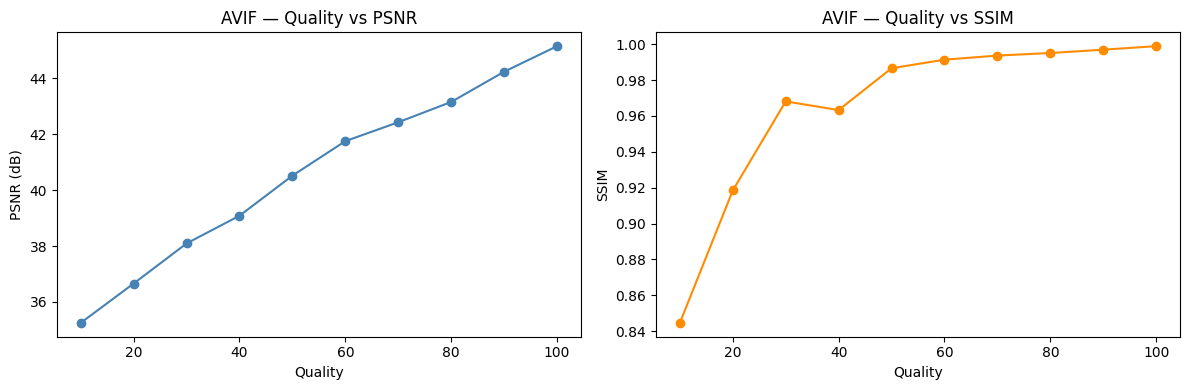

Saved output/quality_metrics_dice_avif.png


In [32]:
# AVIF
# TODO: completeaza codul aici, la fel ca celelalte sectiuni te poti inspira de sus
results_avif = []
for q in qualities:
    comp = np.array(Image.open(f"output/{IMAGE_NAME}_q{q}.avif").convert("RGB"))
    results_avif.append((q, compute_psnr(original, comp), compute_ssim(original, comp)))
    print(f"Quality {q:3d} | PSNR: {results_avif[-1][1]:.2f} dB | SSIM: {results_avif[-1][2]:.4f}")

qs, psnrs, ssims_vals = zip(*results_avif)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(qs, psnrs,      marker="o", color="steelblue");  ax1.set_xlabel("Quality"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("AVIF — Quality vs PSNR")
ax2.plot(qs, ssims_vals, marker="o", color="darkorange"); ax2.set_xlabel("Quality"); ax2.set_ylabel("SSIM");      ax2.set_title("AVIF — Quality vs SSIM")
plt.tight_layout()
plt.savefig(f"output/quality_metrics_{IMAGE_NAME}_avif.png")
plt.show()
print(f"Saved output/quality_metrics_{IMAGE_NAME}_avif.png")

## 6. Vizualizare transformata Fourier imagini: cum afecteaza diferite formate de compresie imaginile

In [33]:
def fft_magnitude(img_array):
    """Return the log-scaled 2-D FFT magnitude spectrum of a grayscale image."""
    gray   = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    return 20 * np.log10(np.abs(fshift) + 1)   # +1 avoids log(0)

def downsample(arr, target=200):
    """Downsample a 2-D array to at most target x target for faster 3-D rendering."""
    sy = max(1, arr.shape[0] // target)
    sx = max(1, arr.shape[1] // target)
    return arr[::sy, ::sx]

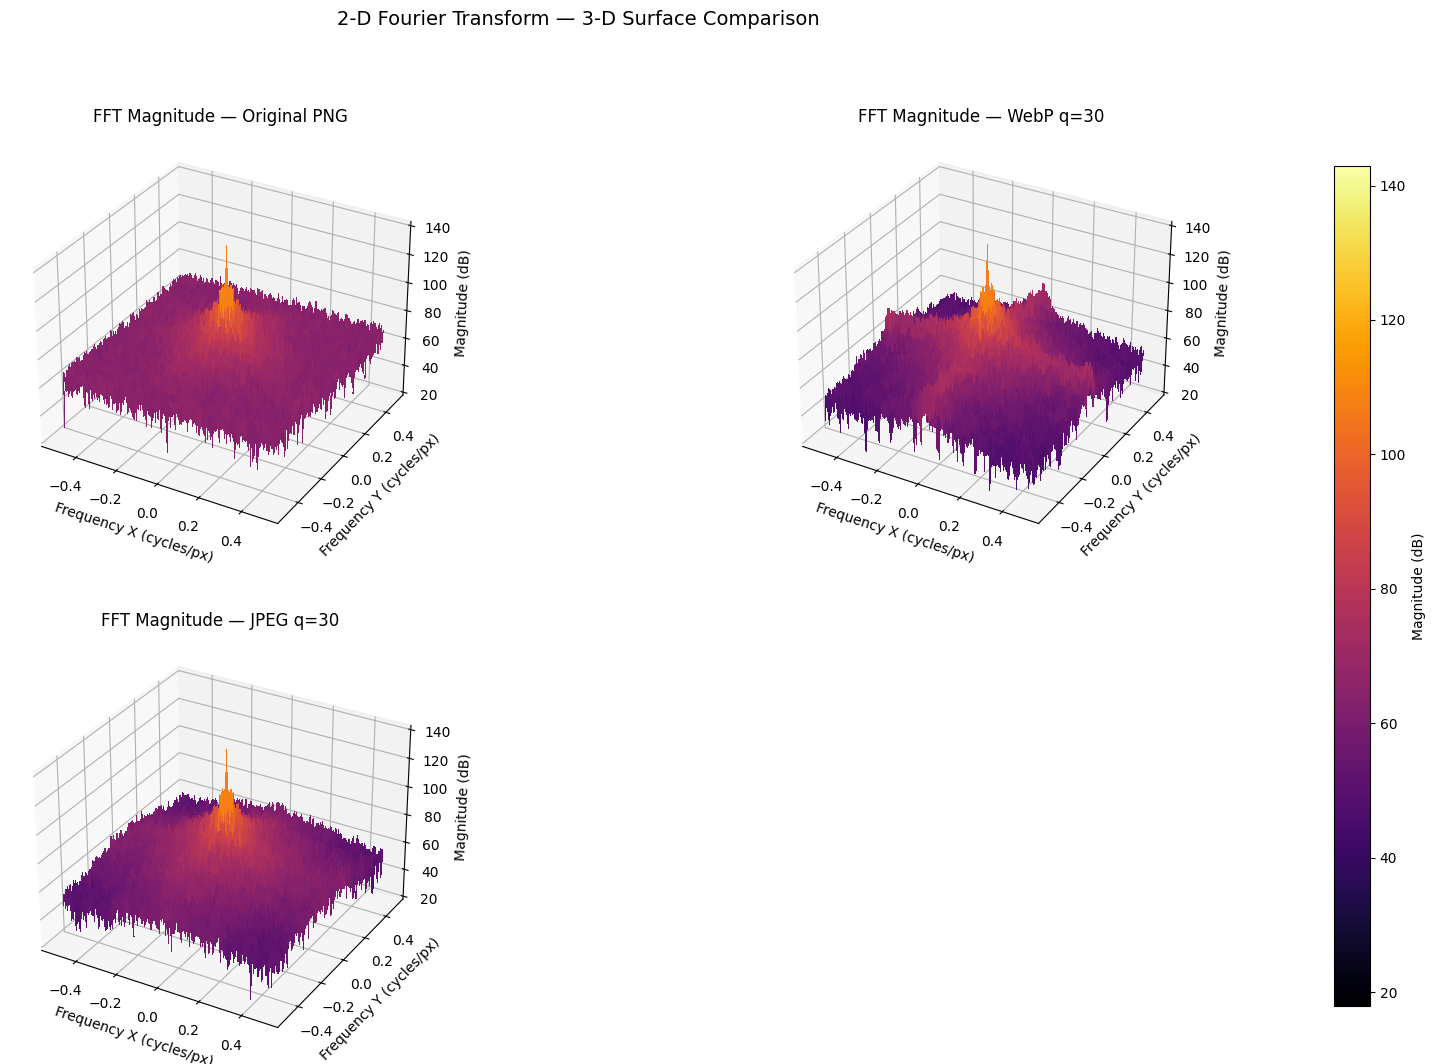

Saved output/fft_comparison_dice.png


In [34]:
# Schimbă fft_quality pentru a compara un nivel diferit de compresie
fft_quality = 30
fft_webp_path    = f"output/{IMAGE_NAME}_q{fft_quality}.webp"
fft_jpeg_path    = f"output/{IMAGE_NAME}_q{fft_quality}.jpg"

original_rgb = np.array(Image.open(IMG).convert("RGB"))
webp_rgb     = np.array(Image.open(fft_webp_path).convert("RGB"))
# TODO: daca adaugi si alte imagini, ai grija sa le dai convert in RGB
jpeg_rgb     = np.array(Image.open(fft_jpeg_path).convert("RGB"))

mag_orig = downsample(fft_magnitude(original_rgb))
mag_webp = downsample(fft_magnitude(webp_rgb))
# TODO: adauga calcularea magnitudini si pt alte formate si vezi diferenta
mag_jpeg = downsample(fft_magnitude(jpeg_rgb))

vmin = min(mag_orig.min(), mag_webp.min())
vmax = max(mag_orig.max(), mag_webp.max())

# Daca ploturile nu se vad bine, creste numerele de aici
fig = plt.figure(figsize=(18, 12))

# TODO: daca adaugi calculul si altor magnitudini atunci o sa trebuiasca
# sa adaugi in lista de mai jos magnitudinea calculata si numele plotului
for idx, (mag, label) in enumerate(
    [(mag_orig, "Original PNG"), (mag_webp, f"WebP q={fft_quality}"), (mag_jpeg, f"JPEG q={fft_quality}")]
):
    rows, cols = mag.shape
    # Axe de frecvență normalizate: -0.5 … +0.5 cicluri/pixel (DC centrat prin fftshift)
    fx = np.fft.fftshift(np.fft.fftfreq(cols))
    fy = np.fft.fftshift(np.fft.fftfreq(rows))
    X, Y = np.meshgrid(fx, fy)

    # TODO: ca sa adaugi mai multe ploturi trebuie sa cresti nr de 
    # ploturi maxime, aici de exemplu putem plota doar 2 ploturi
     
    # primul parametru este numarul de randuri iar al doilea este numarul de coloane 
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d")
    surf = ax.plot_surface(X, Y, mag, cmap="inferno",
                           vmin=vmin, vmax=vmax,
                           linewidth=0, antialiased=False)
    ax.set_title(f"FFT Magnitude — {label}")
    ax.set_xlabel("Frequency X (cycles/px)")
    ax.set_ylabel("Frequency Y (cycles/px)")
    ax.set_zlabel("Magnitude (dB)")
    ax.set_zlim(vmin, vmax)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax, label="Magnitude (dB)")
plt.suptitle("2-D Fourier Transform — 3-D Surface Comparison", fontsize=14)
plt.subplots_adjust(right=0.90)
plt.savefig(f"output/fft_comparison_{IMAGE_NAME}.png", bbox_inches="tight")
plt.show()
print(f"Saved output/fft_comparison_{IMAGE_NAME}.png")